# DigitAI

## Transformando dígitos em inteligência

### Mini-Projeto Avaliativo — Módulo 2

Neste projeto, vamos construir uma solução capaz de reconhecer dígitos manuscritos. A ideia é entender como uma imagem pode ser transformada em dados e como modelos de Machine Learning usam essas informações para classificar números de 0 a 9.

---

## Objetivo do projeto

O DigitAI tem como objetivo construir um pipeline preditivo multiclasse para identificar dígitos manuscritos de 0 a 9 a partir do dataset MNIST (`mnist_784`).

Ao longo do projeto, vamos conhecer a estrutura dos dados, preparar as imagens para o treinamento, comparar três modelos preditivos e avaliar como cada um deles se comporta. Também serão realizados testes de robustez e uma etapa de predição com imagens manuscritas próprias.

# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Antes de treinar qualquer modelo, precisamos entender a base de dados que será utilizada. Nesta primeira etapa, vamos carregar o dataset MNIST e observar como as imagens e seus rótulos estão organizados.

Também vamos verificar o tamanho das matrizes de dados, conferir se os dígitos de 0 a 9 estão bem distribuídos e visualizar alguns exemplos. Por fim, vamos explicar como uma imagem de 28 × 28 pixels é convertida em um vetor de 784 características para que os modelos consigam interpretar essas informações.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [2]:
print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

print("Download finalizado.")

Baixando o dataset MNIST...
Download finalizado.


In [3]:
X = mnist.data
y = mnist.target

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (70000, 784)
y.shape: (70000,)


### Distribuição dos rótulos (0–9)

A tabela abaixo mostra quantas imagens existem para cada dígito no MNIST.

In [4]:
# Contar a quantidade de cada dígito
label_counts = pd.Series(y).value_counts().sort_index()

# Criar DataFrame
df_labels = pd.DataFrame({
    "label": label_counts.index.astype(int),
    "count": label_counts.values
})

print(df_labels)

   label  count
0      0   6903
1      1   7877
2      2   6990
3      3   7141
4      4   6824
5      5   6313
6      6   6876
7      7   7293
8      8   6825
9      9   6958


### Gráfico de distribuição dos rótulos

O gráfico abaixo mostra a quantidade de imagens para cada dígito (0 a 9).

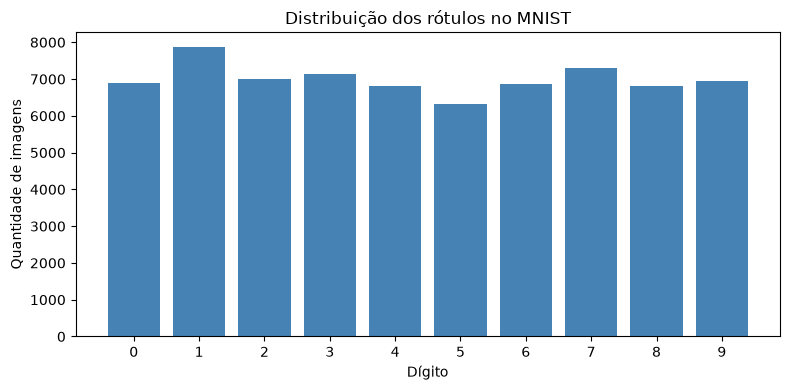

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(df_labels["label"], df_labels["count"], color="steelblue")
plt.xticks(range(10))
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")
plt.title("Distribuição dos rótulos no MNIST")
plt.tight_layout()
plt.show()

### Visualização de exemplos das imagens

As imagens do MNIST são armazenadas inicialmente como vetores com 784 pixels.
Cada vetor será reorganizado em uma matriz de 28 × 28 pixels para visualização.

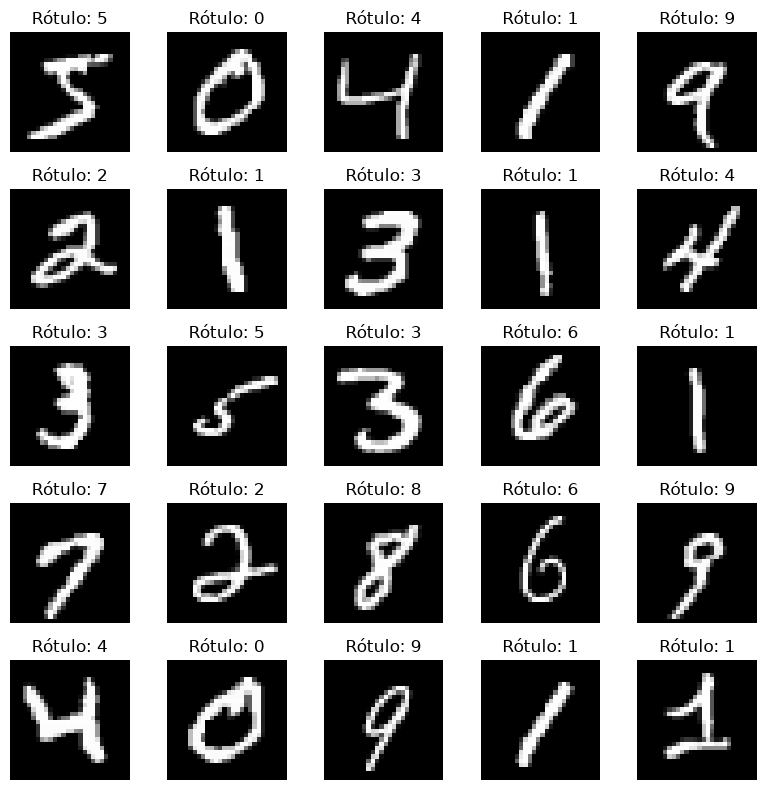

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Rótulo: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observações sobre as imagens

A visualização mostra exemplos de números escritos à mão presentes no dataset MNIST. Mesmo representando os mesmos dígitos, as imagens variam bastante porque cada pessoa escreve de um jeito diferente: alguns traços são mais grossos, outros mais finos, alguns números ficam inclinados e outros ocupam mais espaço na imagem.

Também é possível perceber que alguns dígitos podem se parecer entre si dependendo da forma como foram escritos, como o 1 e o 7, ou o 3 e o 5. Essas diferenças tornam a tarefa de classificação mais interessante, pois o modelo precisará aprender a reconhecer padrões mesmo quando os números não são idênticos.

Os rótulos exibidos acima de cada imagem representam o dígito correto informado pelo dataset. Nesta etapa, eles servem como referência para entender os dados antes de treinar os modelos de classificação.

### Como as imagens são representadas

Cada imagem do MNIST possui 28 pixels de altura e 28 pixels de largura. Por isso, quando observamos a imagem como uma matriz, ela tem o formato 28 × 28.

Cada pixel possui um valor de intensidade entre 0 e 255. O valor 0 representa o preto, enquanto o valor 255 representa o branco. Os valores intermediários representam tons de cinza. Nas imagens exibidas, os números aparecem em tons claros e o fundo é escuro porque usamos o mapa de cores `gray` na visualização.

Para que algoritmos de Machine Learning possam trabalhar com essas imagens, a matriz 28 × 28 é transformada em um único vetor com 784 posições, pois 28 × 28 = 784. Cada posição desse vetor representa a intensidade de um pixel da imagem.

Assim, a matriz `X` possui 70.000 linhas, uma para cada imagem, e 784 colunas, uma para cada pixel. Já o vetor `y` guarda o rótulo correto de cada imagem, ou seja, o dígito que ela representa.